# Test3: Phân loại dữ liệu ngẫu nhiên bằng thuật toán RIPPER
### Môn: Machine Learning
#### Đề 3 - Nguyễn Phúc Minh Châu
---
Trong bài này, sinh viên sẽ xây dựng bộ phân loại dựa trên luật (Rule-based classifier) sử dụng **RIPPER** (Repeated Incremental Pruning to Produce Error Reduction).

**Mục tiêu:**
- Áp dụng thuật toán RIPPER để phân loại dữ liệu.
- Huấn luyện theo hướng **One-vs-Rest (OVR)** để xử lý bài toán đa lớp.
- Đánh giá hiệu năng mô hình bằng các chỉ số: độ chính xác, ma trận nhầm lẫn, báo cáo phân loại.
- Trực quan hóa kết quả dự đoán.


## 1. Import các packages cần thiết

In [1]:
# Cài đặt thư viện nếu chưa có
!pip install wittgenstein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 3.5 MB/s eta 0:00:00


In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import wittgenstein as lw  # thư viện triển khai RIPPER

## 2. Dùng NumPy tạo dataset ngẫu nhiên gồm 300 dòng với 4 đặc trưng và thuộc về 4 loại khác nhau (0, 1, 2, 3). Các đặc trưng là những số thực thuộc đoạn [-1, 1].

In [51]:
# Tạo dataset ngẫu nhiên bằng numpy
np.random.seed(42) # for reproducibility

X = np.random.uniform(low=-1, high=1, size=(300, 4))
y = np.random.randint(low=0, high=4, size=300)

# Combine features and labels into a DataFrame for easier handling
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(4)])
df['class'] = y
df.head()

,feature_0,feature_1,feature_2,feature_3,class
0,-0.250920,0.901429,0.463988,0.197317,0
1,-0.687963,-0.688011,-0.883833,0.732352,3
2,0.202230,0.416145,-0.958831,0.939820,2
3,0.664885,-0.575322,-0.636350,-0.633191,0
4,-0.391516,0.049513,-0.136110,-0.417542,2


## 3. In thông tin của dataset

Số lượng mẫu: 300
Số thuộc tính: 4
Các lớp: [0 3 2 1]

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_0  300 non-null    float64
 1   feature_1  300 non-null    float64
 2   feature_2  300 non-null    float64
 3   feature_3  300 non-null    float64
 4   class      300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB
None


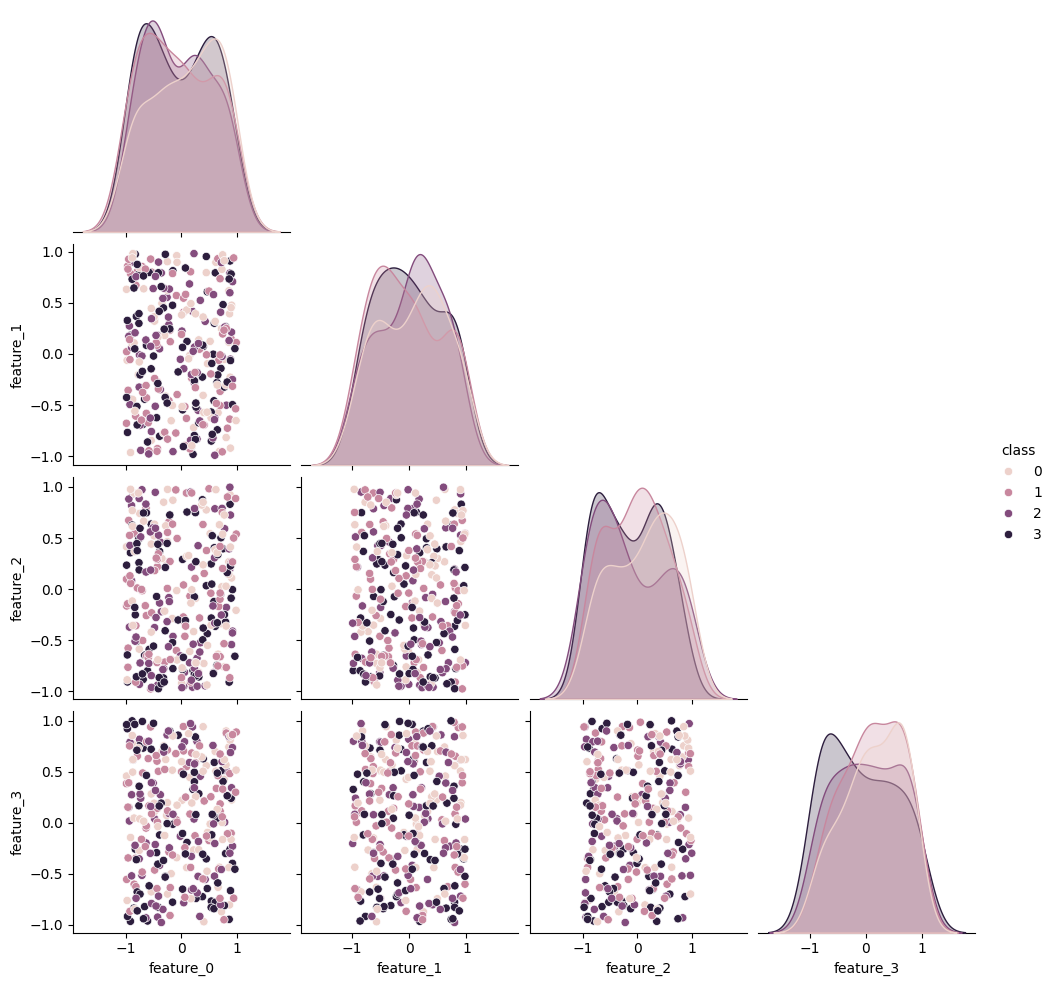

In [52]:
print("Số lượng mẫu:", df.shape[0])
print("Số thuộc tính:", df.shape[1]-1)
print("Các lớp:", df['class'].unique())
print("\nThông tin dữ liệu:")
print(df.info())

sns.pairplot(df, hue='class', corner=True)
plt.show()

## 4. Huấn luyện RIPPER theo One-vs-Rest (OVR)
*Lưu ý: Chia dữ liệu huấn luyện và kiểm tra theo tỷ lệ 80:20*

In [53]:
# Chia dữ liệu huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Huấn luyện 1 mô hình RIPPER cho từng lớp (One-vs-Rest)
classes = np.unique(y)
models = {}

for cls in classes:
    y_binary = (y_train == cls).astype(int)  # lớp hiện tại là 1, lớp khác là 0

    # Ghép X_train và y_binary thành một DataFrame duy nhất
    train_df = pd.DataFrame(X_train.copy())
    train_df["class"] = y_binary

    model = lw.RIPPER()
    model.fit(train_df, class_feat="class", pos_class=1)
    models[cls] = model
    print(f"Mô hình cho lớp '{cls}' được huấn luyện xong.")

Mô hình cho lớp '0' được huấn luyện xong.
Mô hình cho lớp '1' được huấn luyện xong.
Mô hình cho lớp '2' được huấn luyện xong.
Mô hình cho lớp '3' được huấn luyện xong.


## 5. Dự đoán bằng cách chọn class có độ tin cậy (confidence) cao nhất

In [54]:
# Tính độ tin cậy (probability) của mỗi mô hình đối với từng lớp
confidences = pd.DataFrame()
for cls, model in models.items():
    conf = model.predict_proba(X_test)[:, 1]  # xác suất thuộc lớp hiện tại
    confidences[cls] = conf

# Chọn lớp có độ tin cậy cao nhất
y_pred = confidences.idxmax(axis=1)
y_pred.head()

,0
0,1
1,1
2,1
3,1
4,1


## 6. Đánh giá mô hình (in độ chính xác)

In [56]:
acc = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình: {acc:.4f}")

Độ chính xác của mô hình: 0.2833


## 7. Confusion Matrix

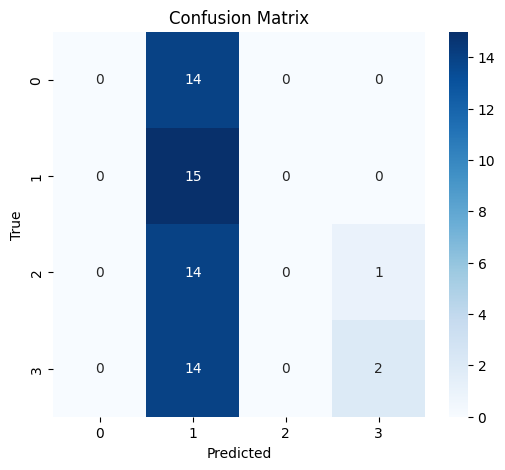

In [57]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 8. Classification Report

In [58]:
print('Báo cáo phân loại:')
print(classification_report(y_test, y_pred))

Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.26      1.00      0.42        15
           2       0.00      0.00      0.00        15
           3       0.67      0.12      0.21        16

    accuracy                           0.28        60
   macro avg       0.23      0.28      0.16        60
weighted avg       0.24      0.28      0.16        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 8. Giải thích Confusion Matrix

Ma trận nhầm lẫn (Confusion Matrix):

Ma trận này cho thấy hiệu suất của mô hình trong việc phân loại từng lớp. Các hàng biểu thị lớp thực tế, các cột biểu thị lớp mà mô hình dự đoán.

- Hàng 0 (Thực tế là lớp 0): Có 14 mẫu thực sự thuộc lớp 0, nhưng mô hình đã dự đoán sai tất cả là lớp 1.
- Hàng 1 (Thực tế là lớp 1): Có 15 mẫu thực sự thuộc lớp 1, và mô hình đã dự đoán đúng tất cả là lớp 1.
- Hàng 2 (Thực tế là lớp 2): Có 15 mẫu thực sự thuộc lớp 2, nhưng mô hình đã dự đoán sai tất cả là lớp 1.
- Hàng 3 (Thực tế là lớp 3): Có 16 mẫu thực sự thuộc lớp 3. Mô hình dự đoán đúng 2 mẫu là lớp 3, nhưng dự đoán sai 14 mẫu là lớp 1.

Nhìn chung, ma trận nhầm lẫn cho thấy mô hình của bạn có xu hướng dự đoán hầu hết các mẫu là lớp 1, bất kể lớp thực tế của chúng là gì.